In [1]:
import matplotlib.pyplot as pl
import numpy as np
import pandas as pd
import xarray as xr
import math

from fair import FAIR
from fair.interface import fill, initialise
from fair.io import read_properties
from pygments.lexers.textfmts import TodotxtLexer

In [2]:
f = FAIR(ch4_method="Thornhill2021")
f.define_time(1750, 2500, 1)  # start, end, step

"""
scenarios = [
    "high-extension",
    "high-overshoot",
    "medium-overshoot",
    "medium-extension",
    "low",
    "verylow",
    "verylow-overshoot",
]
"""

scenarios_Rcimp = ['ssp119', 'ssp126', 'ssp245', 'ssp370', 'ssp434', 'ssp460', 'ssp534-over', 'ssp585']
f.define_scenarios(scenarios_Rcimp)
fair_params_1_4_1_file = 'examples/data/calibrated_constrained_ensemble/calibrated_constrained_parameters_calibration1.4.1.csv'
df_configs = pd.read_csv(fair_params_1_4_1_file, index_col=0)
configs = df_configs.index  # this is used as a label for the "config" axis
f.define_configs(configs)
fair_species_configs_1_4_1_file = 'examples/data/calibrated_constrained_ensemble/species_configs_properties_calibration1.4.1.csv'
species_Rcimp, properties = read_properties(filename=fair_species_configs_1_4_1_file)
f.define_species(species_Rcimp, properties)
f.allocate()
"""
f.fill_from_csv(
    emissions_file='examples/data/calibrated_constrained_ensemble/extensions_1750-2500.csv',
    forcing_file='examples/data/calibrated_constrained_ensemble/volcanic_solar.csv',
)
"""

"\nf.fill_from_csv(\n    emissions_file='examples/data/calibrated_constrained_ensemble/extensions_1750-2500.csv',\n    forcing_file='examples/data/calibrated_constrained_ensemble/volcanic_solar.csv',\n)\n"

In [3]:
f.fill_from_rcmip()

f.forcing.sel(specie="Volcanic")
fill(
    f.forcing,
    f.forcing.sel(specie="Volcanic") * df_configs["forcing_scale[Volcanic]"].values.squeeze(),
    specie="Volcanic",
)
fill(
    f.forcing,
    f.forcing.sel(specie="Solar") * df_configs["forcing_scale[Solar]"].values.squeeze(),
    specie="Solar",
)
f.fill_species_configs(fair_species_configs_1_4_1_file)
f.override_defaults(fair_params_1_4_1_file)
initialise(f.concentration, f.species_configs["baseline_concentration"])
initialise(f.forcing, 0)
initialise(f.temperature, 0)
initialise(f.cumulative_emissions, 0)
initialise(f.airborne_emissions, 0)
initialise(f.ocean_heat_content_change, 0)
f.run()

Running 6728 projections in parallel:   0%|          | 0/750 [00:00<?, ?timesteps/s]

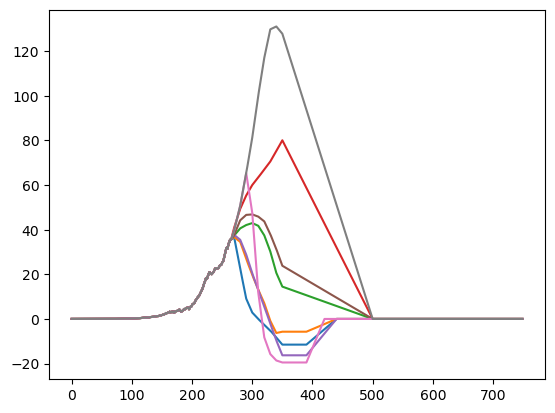

In [4]:
pl.plot(f.emissions.sel(specie = "CO2 FFI", config = 1234))

In [ ]:
fancy_titles = {
    'ssp119': 'ssp119',
    'ssp126': 'ssp126',
    'ssp245': 'ssp245',
    'ssp370': 'ssp370',
    'ssp434': 'ssp434',
    'ssp460': 'ssp460',
    'ssp534-over': 'ssp534-over',
    'ssp585': 'ssp585'
}

colors = {
    'ssp119': '#0000FF',    # Dark blue for lowest emissions
    'ssp126': '#4169E1',    # Royal blue
    'ssp245': '#00BFFF',    # Deep sky blue
    'ssp370': '#FFD700',    # Gold
    'ssp434': '#FFA500',    # Orange
    'ssp460': '#FF4500',    # Orange red
    'ssp534-over': '#DC143C',    # Crimson
    'ssp585': '#8B0000'     # Dark red for highest emissions
}

weights_51yr = np.ones(52)
weights_51yr[0] = 0.5
weights_51yr[-1] = 0.5

: 

In [ ]:
# save fair object
import pickle

with open("origional_model.pkl", "wb") as f_out:
    pickle.dump(f, f_out)

In [ ]:
"""fig, ax = pl.subplots(2, 4, figsize=(12, 6))

for i, scenario in enumerate(f.scenarios):
    for pp in ((0, 100), (5, 95), (16, 84)):
        ax[i // 4, i % 4].fill_between(
            f.timebounds,
            np.percentile(
                f.temperature.loc[dict(scenario=scenario, layer=0)]
                - np.average(
                    f.temperature.loc[
                        dict(scenario=scenario, timebounds=np.arange(1850, 1902), layer=0)
                    ],
                    weights=weights_51yr,
                    axis=0
                ),
                pp[0],
                axis=1,
            ),
            np.percentile(
                f.temperature.loc[dict(scenario=scenario, layer=0)]
                - np.average(
                    f.temperature.loc[
                        dict(scenario=scenario, timebounds=np.arange(1850, 1902), layer=0)
                    ],
                    weights=weights_51yr,
                    axis=0
                ),
                pp[1],
                axis=1,
            ),
            color=colors[f.scenarios[i]],
            alpha=0.2,
            lw=0
        )

    ax[i // 4, i % 4].plot(
        f.timebounds,
        np.median(
            f.temperature.loc[dict(scenario=scenario, layer=0)]
            - np.average(
                f.temperature.loc[
                    dict(scenario=scenario, timebounds=np.arange(1850, 1902), layer=0)
                ],
                weights=weights_51yr,
                axis=0
            ),
            axis=1,
        ),
        color=colors[f.scenarios[i]],
    )
    ax[i // 4, i % 4].set_xlim(1850, 2300)
    ax[i // 4, i % 4].set_ylim(-1, 10)
    ax[i // 4, i % 4].axhline(0, color="k", ls=":", lw=0.5)
    ax[i // 4, i % 4].set_title(fancy_titles[f.scenarios[i]])

pl.suptitle("Temperature anomalies")
fig.tight_layout()"""

'fig, ax = pl.subplots(2, 4, figsize=(12, 6))\n\nfor i, scenario in enumerate(f.scenarios):\n    for pp in ((0, 100), (5, 95), (16, 84)):\n        ax[i // 4, i % 4].fill_between(\n            f.timebounds,\n            np.percentile(\n                f.temperature.loc[dict(scenario=scenario, layer=0)]\n                - np.average(\n                    f.temperature.loc[\n                        dict(scenario=scenario, timebounds=np.arange(1850, 1902), layer=0)\n                    ],\n                    weights=weights_51yr,\n                    axis=0\n                ),\n                pp[0],\n                axis=1,\n            ),\n            np.percentile(\n                f.temperature.loc[dict(scenario=scenario, layer=0)]\n                - np.average(\n                    f.temperature.loc[\n                        dict(scenario=scenario, timebounds=np.arange(1850, 1902), layer=0)\n                    ],\n                    weights=weights_51yr,\n                    axis=0

: 